In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
config_path = "experiments/benchmark_output_files/mouse_embryo.yaml"

In [3]:
from src.experiments_analysis.plots_ismb import (
    colorblind_palette,
    model_name_replacement_dict,
    color_dict
)

from src.experiments_analysis.analysis_simulated_data_pipeline import analysis
import yaml
from pathlib import Path as P

cfg = yaml.safe_load(open(config_path))

output_dir = cfg["output_dir"]
runs = cfg["runs"]
dividing_by_ratio_baselines = cfg["dividing_by_ratio_baselines"]
not_factor_based_baseline = cfg["not_factor_based_baseline"]
supp_baselines_dir = cfg["supp_baselines_dir"]

main_publi_output_folder = P(cfg["main_publi_output_folder"])
main_publi_output_folder.mkdir(exist_ok=True, parents=True)
supp_publi_output_folder = P(cfg["supp_publi_output_folder"])
supp_publi_output_folder.mkdir(exist_ok=True, parents=True)

global_structure_analysis_folder = P(output_dir) / "global_structure_analysis"
supp_publi_output_folder = cfg["supp_publi_output_folder"]
P(supp_publi_output_folder).mkdir(exist_ok=True, parents=True)

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [4]:
analysis(
    output_dir,
    runs,
    dividing_by_ratio_baselines,
    not_factor_based_baseline,
    supp_baselines_dir,
    synthetic_data=False
)

,name,converged
0,ours,True
1,ours__P2_identity,True
2,original,NaN
3,dividing_median_ratio,NaN
4,dividing_median,NaN
5,dividing_median_quantile_nucl,NaN
6,dividing_99_quantile_nucl,NaN
7,dividing_99_quantile,NaN
8,2SN,NaN
9,bin_level_normalization,NaN


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)


2SN 0
bin_level_normalization 1
dividing_99_quantile 2
dividing_99_quantile_nucl 3
dividing_median 4
dividing_median_quantile_nucl 5
dividing_median_ratio 6
original 7
ours 8
ours__P2_identity 9


striping intensity in cytoplasm
striping intensity in cytoplasm
striping intensity in cytoplasm + nucleus
striping intensity in cytoplasm + nucleus


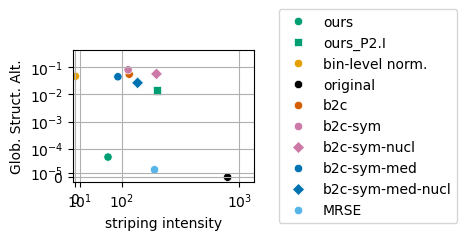

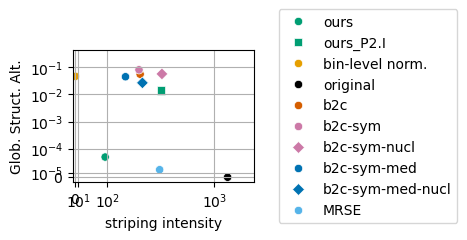

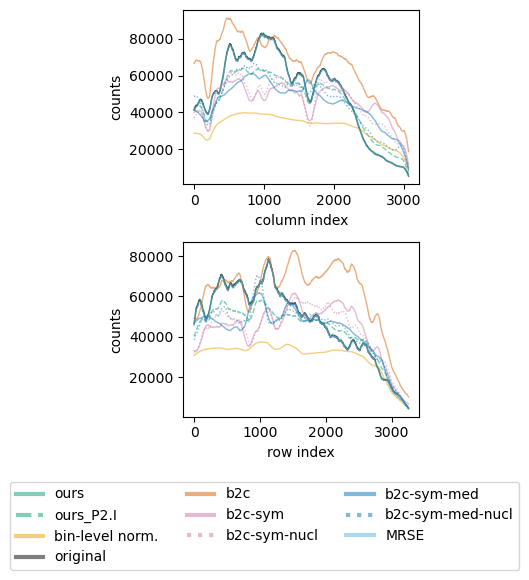

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:945: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


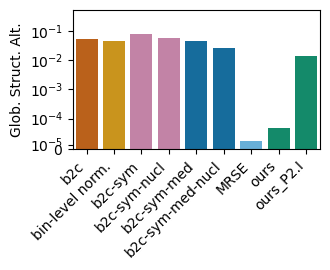

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:945: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


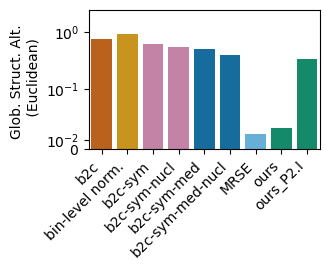

In [4]:
from src.experiments_analysis.analysis_plots import global_structure_plot_all_methods
from pathlib import Path as P

global_structure_analysis_folder = P(output_dir) / "global_structure_analysis"
supp_publi_output_folder = cfg["supp_publi_output_folder"]
P(supp_publi_output_folder).mkdir(exist_ok=True, parents=True)

global_structure_plot_all_methods(global_structure_analysis_folder, supp_publi_output_folder)

## Qualitative results

We show that:
1) we capture better the original gradient of the slide
2) a region where we achieve better destriping

Using vmin, vmax = 1.0 446.0


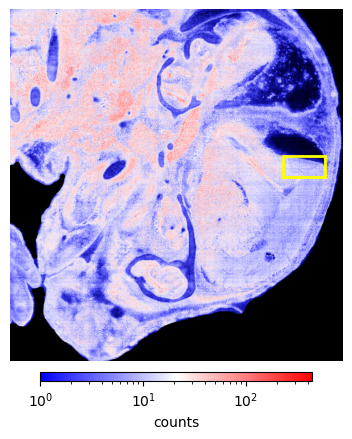

In [5]:
from src.experiments_analysis.analysis_plots import region_overview_plot
from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
from cmap import Colormap
import matplotlib.pyplot as plt
from pathlib import Path as P

height_colorbar=0.092

regions = {
    "zoom": (slice(1400, 1600), slice(2600, 3000))
}

colors_region = {
    "zoom": "yellow",
}

abbr_region = {"zoom": ""}
imshow_kwargs = {"cmap": "bwr"}
rectangle_kwargs = {"alpha": 1}

norm = LogNorm()
region_overview_plot("original", regions, colors_region, abbr_region, global_structure_analysis_folder, model_name_replacement_dict, norm, height_colorbar, imshow_kwargs=imshow_kwargs, rectangle_kwargs=rectangle_kwargs)

plt.savefig(P(main_publi_output_folder) / "regions_overview.pdf")

### global intensity

Using vmin, vmax = 0.0 446.0


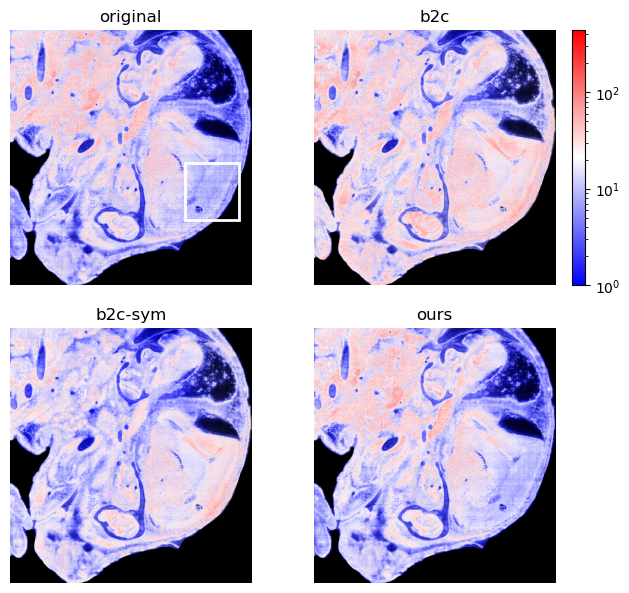

In [6]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots,
)
from src.utilities.matplotlib_utils import save_pdf_temp_intermediate
import matplotlib.pyplot as plt
from pathlib import Path as P
from matplotlib.colors import PowerNorm, LogNorm
from src.experiments_analysis.analysis_plots import slice_to_rect
from matplotlib.patches import Rectangle
import numpy as np

to_plot = ["original", "b2c", "b2c-sym", "ours"]
region_slice = (slice(None, None), slice(None, None))
fig, axes = plt.subplots(2,2, figsize=(3.4 *2, 3 * 2))
axes = compare_destriped_data_plots(to_plot, global_structure_analysis_folder, region_slice, model_name_replacement_dict, axes = axes.flatten(), cmap = "bwr")

new_norm = LogNorm()
[ax.images[0].set_norm(new_norm) for ax in axes]
[ax.axis("off") for ax in axes]

for cax in np.array(fig.axes).flatten():
    if (cax.get_label() != "<colorbar>") and (cax.get_title() != "b2c"):
        cax.get_images()[0].colorbar.ax.set_visible(False)

bottom_right_region = (slice(1750, 2500), slice(2300, 3000))
x, y, w, h = slice_to_rect(bottom_right_region[0], bottom_right_region[1])
rectangle_kwargs = {"fill": False, "linewidth": 2, "color": "white", "alpha": 1}
axes[0].add_patch(Rectangle((x, y), w, h, **rectangle_kwargs))

plt.tight_layout()

output_path = P(main_publi_output_folder) / "whole_slide.pdf"
save_pdf_temp_intermediate("temp_outputs", output_path)

plt.show()

### Quantification of mean intensity in the bottom right

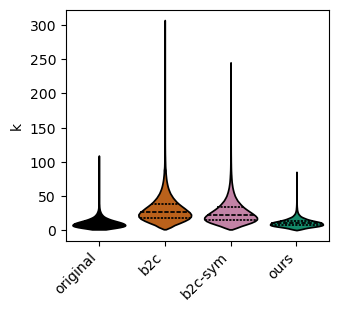

In [7]:
from src.experiments_analysis.analysis_plots import (
    intensity_profile_in_region_violinplot,
)
import matplotlib.pyplot as plt


intensity_profile_in_region_violinplot(
    bottom_right_region,
    to_plot,
    global_structure_analysis_folder,
    color_dict,
    model_name_replacement_dict,
)
plt.savefig(P(main_publi_output_folder) / "zoom_intensity_quantification.pdf", bbox_inches = "tight")
plt.show()

### Region where better destriping than bin2cell

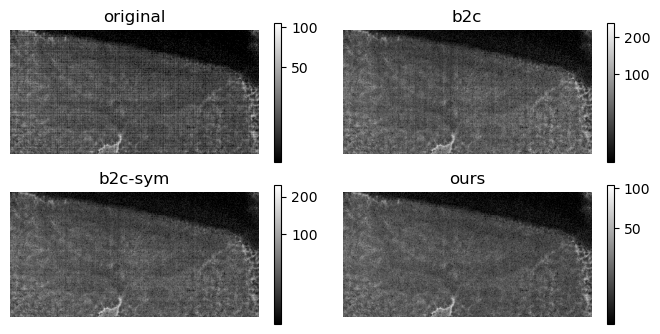

cytoplasmic striping intensity


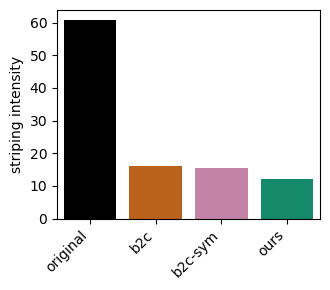

overall striping intensity


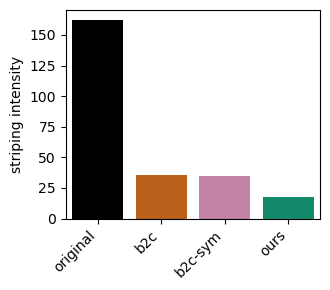

In [8]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots,
    striping_intensity_quantification_region_barplot_all,
)
import matplotlib.pyplot as plt

region_slice = (slice(1400, 1600), slice(2600, 3000))
region_name = "zoom_1"
fig, axes = plt.subplots(2, 2, figsize=(3.4 * 2, 1.7 * 2))
axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    region_slice,
    model_name_replacement_dict,
    axes=axes.flatten(), 
    colorbar_same_scale=False,
)

[ax.images[0].set_norm(PowerNorm(gamma = 0.5)) for ax in axes]
[ax.axis("off") for ax in axes]

plt.tight_layout()

plt.savefig(P(main_publi_output_folder) / f"{region_name}.pdf", dpi = 600)

plt.show()

striping_intensity_quantification_region_barplot_all(
    output_dir,
    region_slice,
    region_name,
    to_plot,
    color_dict,
    model_name_replacement_dict,
    main_publi_output_folder,
)

plt.show()

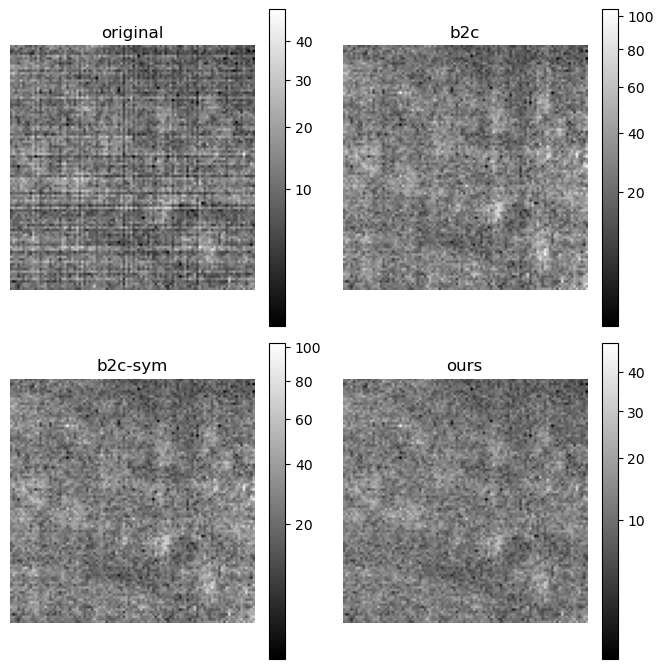

cytoplasmic striping intensity


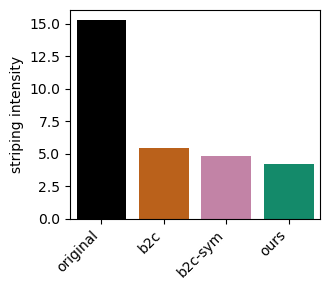

overall striping intensity


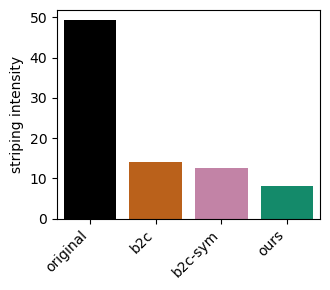

In [9]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots,
)
import matplotlib.pyplot as plt

region_slice = (slice(1450, 1550), slice(2700, 2800))
region_name = "zoom_2"

fig, axes = plt.subplots(2, 2, figsize=(3.4 * 2, 3.4 * 2))
axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    region_slice,
    model_name_replacement_dict,
    axes=axes.flatten(),
    colorbar_same_scale=False,
)

[ax.images[0].set_norm(PowerNorm(gamma=0.5)) for ax in axes]
[ax.axis("off") for ax in axes]

# for cax in np.array(fig.axes).flatten():
#     if (cax.get_label() != "<colorbar>") and (cax.get_title() != "2SN"):
#         cax.get_images()[0].colorbar.ax.set_visible(False)

plt.tight_layout()

plt.savefig(P(main_publi_output_folder) / f"{region_name}.pdf")

plt.show()

striping_intensity_quantification_region_barplot_all(
    output_dir,
    region_slice,
    region_name,
    to_plot,
    color_dict,
    model_name_replacement_dict,
    main_publi_output_folder,
)

plt.show()

plt.show()